In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Narendra Work Files\Data Analyst\CSV Files\animal_data_reworked.csv")
df

,Unnamed: 0,Animal_type,Country,Weight_in_kg,Body_length_in_cm,Gender,Latitude,Longitude,Animal_name,Observation_date,Data_compiled_by
0,2,European bison,Poland,930.000,335.0,male,52.828845,23.820144,Szefu,2024-03-01,Anne Anthony
1,3,European bison,Poland,909.000,311.0,not determined,52.830509,23.826849,unknown,2024-03-01,Anne Anthony
2,4,European bison,Poland,581.000,277.0,female,52.834109,23.807093,unknown,2024-03-01,Anne Anthony
3,5,European bison,Poland,900.000,295.0,male,52.834759,23.817201,unknown,2024-03-01,Anne Anthony
4,6,European bison,Poland,620.000,250.0,female,52.834960,23.820750,unknown,2024-03-01,Anne Anthony
...,...,...,...,...,...,...,...,...,...,...,...
828,1005,hedgehog,Hungary,0.900,23.0,male,47.510055,18.944356,unknown,2024-05-07,Anne Anthony
829,1006,red squirrel,Poland,0.346,20.0,female,52.212001,21.033187,Lola,2024-05-07,Anne Anthony
830,1007,hedgehog,Germany,1.000,23.0,female,49.561356,11.105334,unknown,2024-05-07,Bob Bobson
831,1008,hedgehog,Germany,0.500,17.0,female,49.561569,11.087046,unknown,2024-05-07,Bob Bobson


# Cleaning Steps

# Step 1 Remove Unnecessary Column

In [3]:
df.drop(columns="Unnamed: 0", inplace=True)

# Step 2 Check Duplicates

In [5]:
df.duplicated().sum()

np.int64(0)

# Step 3 Convert Date Column

In [8]:
df["Observation_date"] = pd.to_datetime(df["Observation_date"],errors="coerce")

# Step 4 Fill Missing Latitude & Longitude

In [11]:
df["Latitude"] = df["Latitude"].fillna(df["Latitude"].median())
df["Longitude"] = df["Longitude"].fillna(df["Longitude"].median())

# Step 5 Clean Text Columns

In [12]:
text_cols = ["Animal_type","Country","Gender","Animal_name","Data_compiled_by"]
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

# Step 6 Check Data Types

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Animal_type        833 non-null    str           
 1   Country            833 non-null    str           
 2   Weight_in_kg       833 non-null    float64       
 3   Body_length_in_cm  833 non-null    float64       
 4   Gender             833 non-null    str           
 5   Latitude           833 non-null    float64       
 6   Longitude          833 non-null    float64       
 7   Animal_name        833 non-null    str           
 8   Observation_date   833 non-null    datetime64[us]
 9   Data_compiled_by   833 non-null    str           
dtypes: datetime64[us](1), float64(4), str(5)
memory usage: 65.2 KB


1. Summary Statistics

In [15]:
df.describe()

,Weight_in_kg,Body_length_in_cm,Latitude,Longitude,Observation_date
count,833.000000,833.000000,833.000000,833.000000,833
mean,46.720602,42.501043,49.723397,17.720035,2024-03-31 14:50:16.566626
min,0.200000,11.000000,47.316383,11.074008,2024-03-01 00:00:00
25%,0.297367,19.000000,48.229837,14.382184,2024-03-10 00:00:00
50%,0.349000,21.000000,49.545885,18.847488,2024-03-29 00:00:00
75%,1.000000,23.000000,50.881003,20.558726,2024-04-14 00:00:00
max,1100.000000,350.000000,52.853843,23.919668,2024-06-30 00:00:00
std,168.843218,62.879887,1.758173,3.701566,NaN


2. Summary of Categorical Columns

In [16]:
df.describe(include="object")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5324\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Animal_type,Country,Gender,Animal_name,Data_compiled_by
count,833,833,833,833,833
unique,4,6,4,10,4
top,Red Squirrel,Poland,Male,Unknown,Anne Anthony
freq,421,192,423,813,310


3. Unique Values

In [17]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Animal_type
Animal_type
Red Squirrel      421
Hedgehog          278
Lynx               71
European Bison     63
Name: count, dtype: int64

Country
Country
Poland            192
Germany           178
Slovakia          151
Hungary           118
Czech Republic    116
Austria            78
Name: count, dtype: int64

Gender
Gender
Male              423
Female            401
Not Determined      5
Unknown             4
Name: count, dtype: int64

Animal_name
Animal_name
Unknown     813
Basia         5
Lola          5
Lolek         2
Zuzia         2
Sissi         2
Szefu         1
Klucha        1
Bibi          1
Puchatek      1
Name: count, dtype: int64

Data_compiled_by
Data_compiled_by
Anne Anthony     310
Bob Bobson       256
John Johnson     249
James Johnson     18
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5324\1325783283.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


# Charts

# 1. Animal Type Count (Bar Chart)

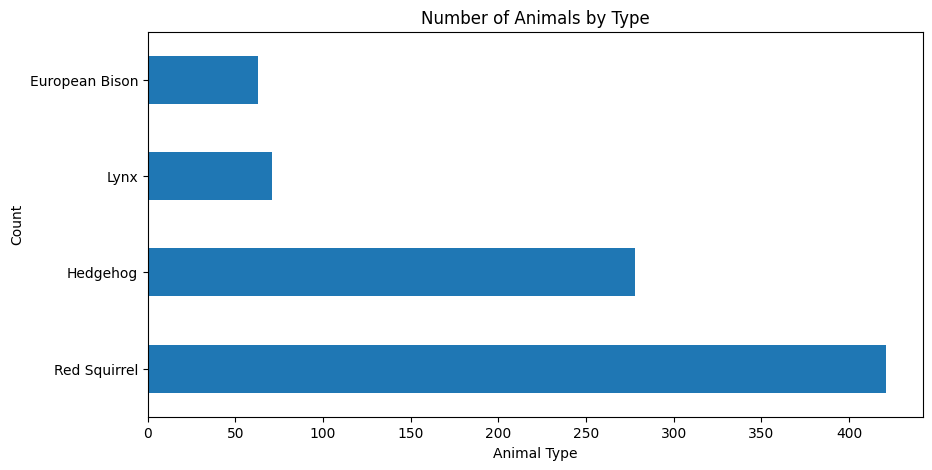

In [24]:
df["Animal_type"].value_counts().plot(
    kind="barh",
    figsize=(10,5),
    title="Number of Animals by Type"
)

plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 2. Country Distribution

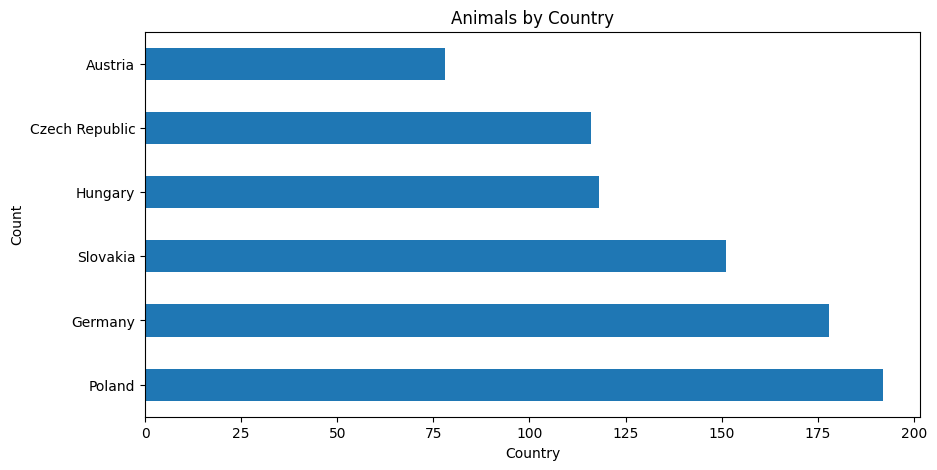

In [23]:
df["Country"].value_counts().plot(
    kind="barh",
    figsize=(10,5),
    title="Animals by Country"
)

plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 3. Gender Distribution (Pie Chart)

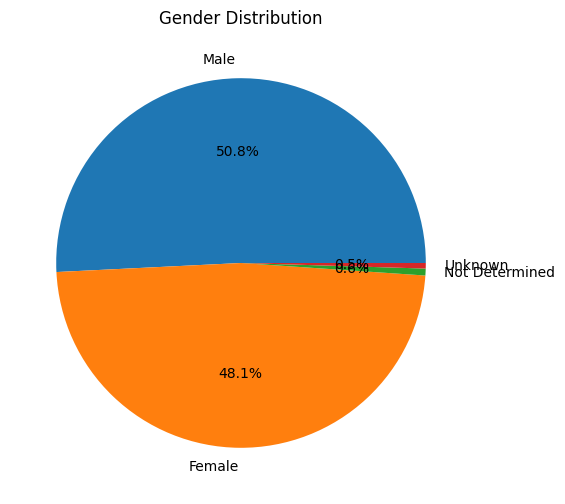

In [25]:
df["Gender"].value_counts().plot(kind="pie",autopct="%1.1f%%",figsize=(6,6))
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

# 4. Weight Distribution

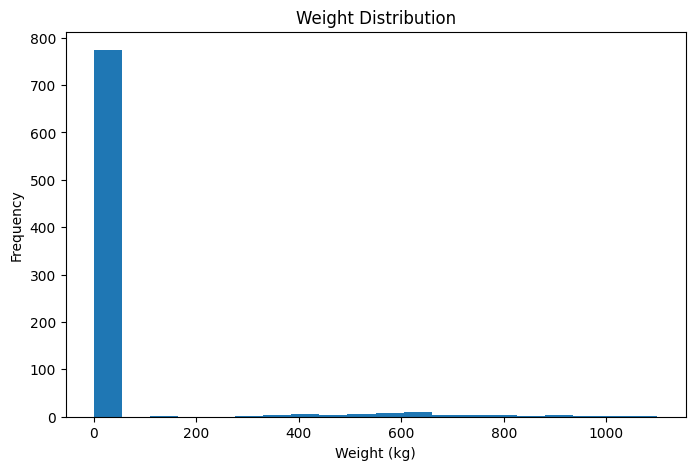

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df["Weight_in_kg"], bins=20)

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.show()

# 5. Body Length Distribution

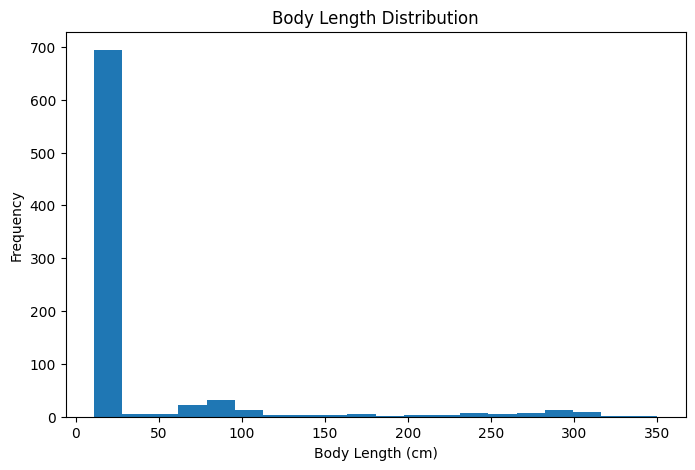

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df["Body_length_in_cm"], bins=20)

plt.title("Body Length Distribution")
plt.xlabel("Body Length (cm)")
plt.ylabel("Frequency")
plt.show()

# 6. Weight vs Body Length (Scatter Plot)

<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

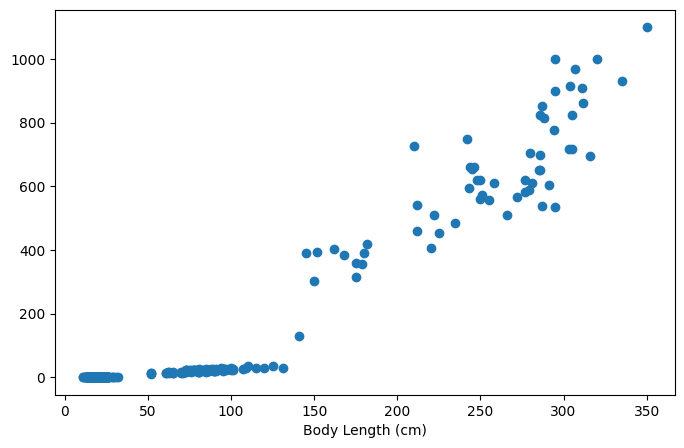

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df["Body_length_in_cm"], df["Weight_in_kg"])

plt.xlabel("Body Length (cm)")
plt.ylabel